# Titanic Dataset - Exploratory Data Analysis
This notebook explores the Titanic dataset to understand survival patterns based on gender, age, and passenger class.

## 1. Importing Libraries
We import pandas and numpy for data manipulation, and matplotlib for visualization.

In [ ]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt

## 2. Loading the Data
Loading the training and test datasets and taking a quick peek at the structure.

In [42]:
titanic_train = pd.read_csv('train.csv')


In [4]:
titanic_train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Inspection
Checking the shape, data types, and missing values before cleaning.

In [6]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 4. Handling Missing Values
- **Age**: Filling with median (robust to outliers)
- **Cabin**: Dropping — too many missing values (~77%)
- **Embarked**: Filling with mode (most frequent port)

In [9]:
titanic_train['Age'] = titanic_train['Age'].fillna(titanic_train['Age'].median())

In [10]:
titanic_train['Age'].isnull().sum()

np.int64(0)

In [11]:
 titanic_train.drop('Cabin', axis = 1 , inplace = True)

In [43]:
titanic_train['Embarked'] = titanic_train['Embarked'].fillna(titanic_train['Embarked'].mode()[0])

## 5. Survival Analysis
Exploring overall survival rate and how it varies across gender and passenger class.

In [14]:
titanic_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [16]:
titanic_train['Survived'].value_counts(normalize = True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [22]:
titanic_train.groupby('Sex')[['Survived']].mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


In [24]:
titanic_train.groupby('Pclass')[['Survived']].mean()*100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


## 6. Visualizations
Bar charts to visualize survival distribution across key features.

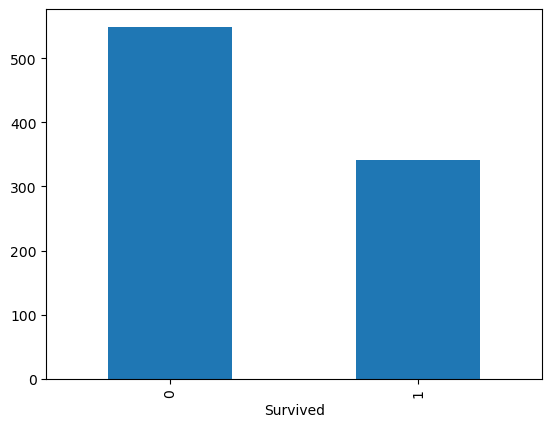

In [29]:
titanic_train['Survived'].value_counts().plot(kind = 'bar')
plt.title = 'Survival Count'
plt.show()

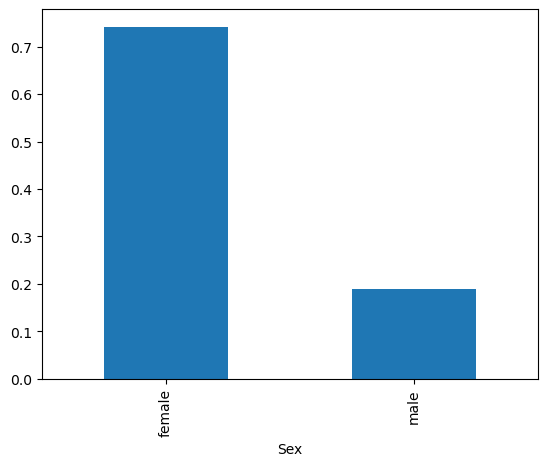

In [35]:
titanic_train.groupby('Sex')['Survived'].mean().plot(kind = 'bar')
plt.title = 'Survival Rate by gender'

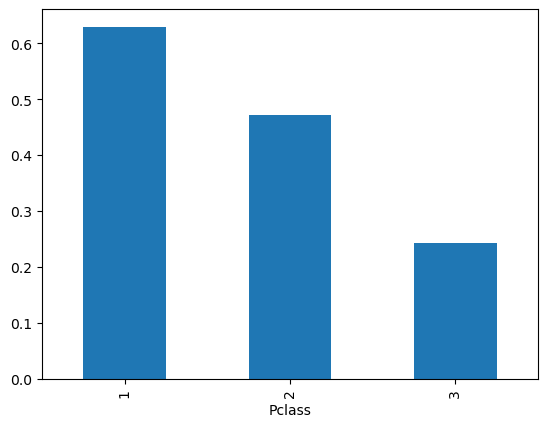

In [37]:
titanic_train.groupby('Pclass')['Survived'].mean().plot(kind = 'bar')
plt.title = 'Survival Rate by Passenger class'

## 7. Key Findings
- Women had a significantly higher survival rate than men
- 1st class passengers survived at a much higher rate than 3rd class
- Age shows varied survival — younger passengers had slightly better odds